# Wine Quality Prediction — Data Science Project

**Student Name: Muhammed Rinshad**

## 1. Import Libraries & Load Dataset

In [1]:
# Upload the Wine Quality CSV file
from google.colab import files
import os

uploaded = files.upload()

csv_files = [name for name in uploaded.keys() if name.lower().endswith('.csv')]
if not csv_files:
    raise FileNotFoundError('Please upload the Wine Quality CSV file.')

CSV_FILE = csv_files[0]
print('Uploaded file:', CSV_FILE)

Saving Wine Quality Dataset.csv to Wine Quality Dataset.csv
Uploaded file: Wine Quality Dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv(CSV_FILE)
print('Dataset loaded successfully!')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully!
Shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumn info:")
df.info()

Shape of dataset: (4898, 12)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [ ]:
# Basic validation
if 'quality' not in df.columns:
    raise ValueError("The uploaded CSV must contain a 'quality' column.")

print('Columns:', list(df.columns))
print('Missing values:', int(df.isnull().sum().sum()))

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Missing values: 0


## 2. Exploratory Data Analysis (EDA)

### 2.1 Check for missing values

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


No missing values in the dataset — no imputation needed.

### 2.2 Target variable distribution

quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


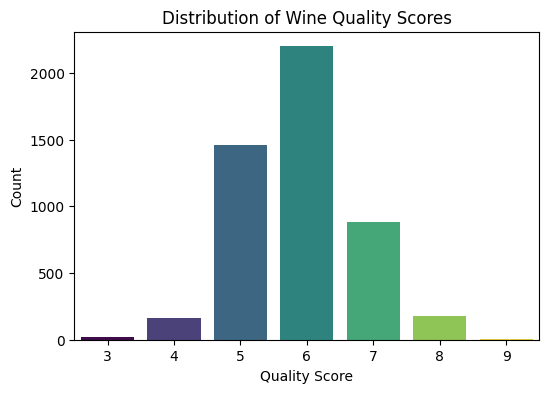

In [ ]:
print(df['quality'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
sns.countplot(x="quality", data=df, hue="quality", palette="viridis", legend=False)
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

The target is **imbalanced** — most wines score 5, 6, or 7, while scores 3 and 9 are rare (only 20 and 5 samples respectively). This will make it harder for any model to correctly classify the extreme classes.

### 2.3 Correlation Analysis

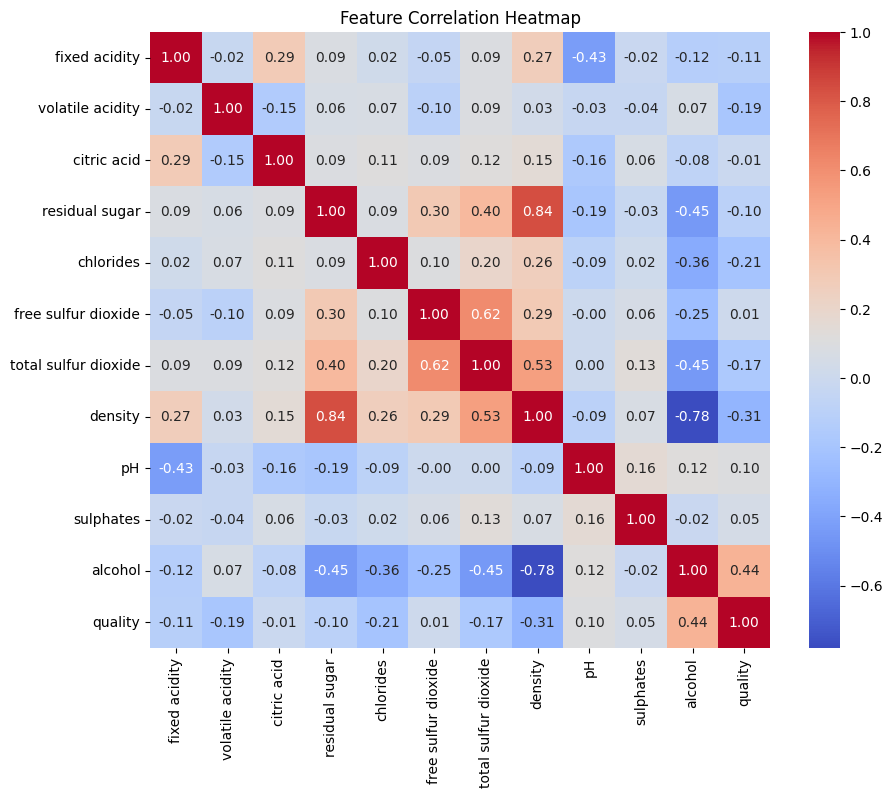

quality                 1.000000
alcohol                 0.435575
pH                      0.099427
sulphates               0.053678
free sulfur dioxide     0.008158
citric acid            -0.009209
residual sugar         -0.097577
fixed acidity          -0.113663
total sulfur dioxide   -0.174737
volatile acidity       -0.194723
chlorides              -0.209934
density                -0.307123
Name: quality, dtype: float64


In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

print(df.corr()['quality'].sort_values(ascending=False))

**Key observations:**
- `alcohol` has the strongest positive correlation with quality (r ≈ 0.44)
- `density` has the strongest negative correlation (r ≈ -0.31)
- Most other features have weak individual correlations, suggesting quality depends on a combination of features rather than any single one

## 3. Data Preprocessing

In [ ]:
X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3918
Testing samples: 980


- **Stratified split** used to preserve the class distribution across train/test sets given the imbalance.
- **StandardScaler** applied to normalize feature scales (important since features range from pH ~3 to sulfur dioxide in the hundreds).

## 4. Model Building — Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)
print("Model trained.")

Model trained.


## 5. Model Evaluation

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")
print()
print(classification_report(y_test, y_pred, zero_division=0))

Test Accuracy: 0.6571

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.57      0.12      0.20        33
           5       0.69      0.63      0.66       291
           6       0.62      0.80      0.70       440
           7       0.70      0.48      0.57       176
           8       1.00      0.49      0.65        35
           9       0.00      0.00      0.00         1

    accuracy                           0.66       980
   macro avg       0.51      0.36      0.40       980
weighted avg       0.67      0.66      0.64       980



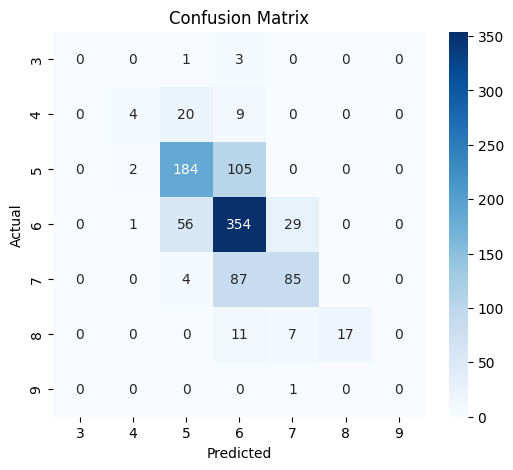

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Interpretation:**
- Overall accuracy is **65.7%**, reasonable for a 7-class problem with strong imbalance.
- The model performs well on the majority classes (5, 6, 7).
- It struggles on rare classes (3, 4, 9) because there are too few training examples to learn their patterns — a common and expected limitation with imbalanced data.

## 6. Feature Importance

alcohol                 0.123836
volatile acidity        0.104913
density                 0.102793
free sulfur dioxide     0.091051
residual sugar          0.088311
total sulfur dioxide    0.087231
chlorides               0.085460
pH                      0.084436
citric acid             0.081055
sulphates               0.077340
fixed acidity           0.073574
dtype: float64


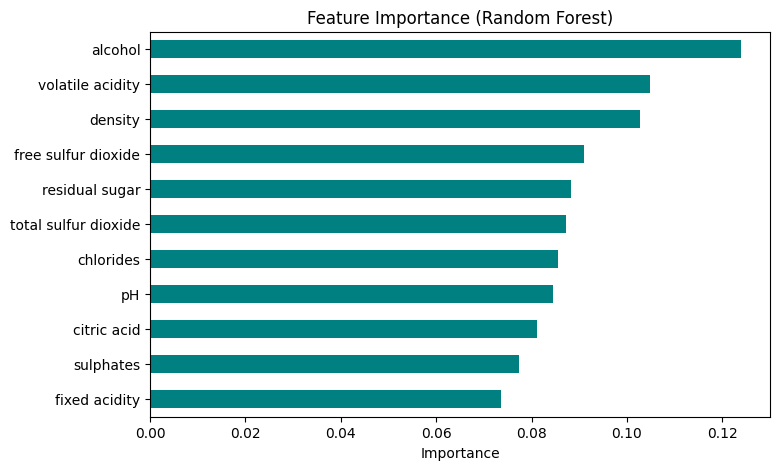

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="teal")
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

## 7. Conclusion

- The Wine Quality dataset (4898 white wine samples, 11 features) has **no missing values**.
- The target variable `quality` is **imbalanced**, dominated by scores 5, 6, and 7.
- **Alcohol content** is the strongest single predictor of quality, followed by **volatile acidity** and **density**.
- A **Random Forest Classifier** achieved **65.7% test accuracy**, performing well on common quality scores but weaker on rare ones due to limited data.

**Possible improvements:**
- Address class imbalance using techniques like SMOTE or class weighting
- Try gradient boosting models (XGBoost, LightGBM) for potentially higher accuracy
- Treat the problem as regression (predicting a continuous quality score) instead of classification
- Collect more samples for underrepresented quality classes